In [1]:
import MDAnalysis as mda
import numpy as np
import re
import matplotlib.pyplot as plt
import pandas as pd
from MDAnalysis.lib.nsgrid import FastNS
from MDAnalysis.lib import mdamath 
from collections import defaultdict
from scipy.spatial import cKDTree
import math
import os
import matplotlib.pyplot as plt

lammps_data = 'lammps.data'
trajectory_file = 'traj.lammpstrj'
u = mda.Universe(lammps_data, trajectory_file, format='LAMMPSDUMP')


/home/user/anaconda3/lib/python3.12/site-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


In [2]:

total_chains = 600                                                                
polymer_typeA = 1                                       
polymer_typeB = 2 
receptor_typeC = 3                                       
receptor_typeD = 4

num_bins = 50
max_distance = 50                                                          
bins = np.linspace(0, max_distance, num_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

z_slab = 115.0                                                              
buffer = 0.0   
                        
x_min, x_max = -40, 40
y_min, y_max = -40, 40
z_min, z_max = 32.2, 34.8


In [3]:
def any_common_elements(list1, list2):
    set1 = set(list1)
    for element in set1:
        if element in list2:
            return True
    return False

def partner_array(resid_interest, cutoff, universe):
    array_partner = [resid_interest]
    atom_list = universe.select_atoms(f"around {cutoff:.2f} (resid {resid_interest})")
    for atom in atom_list:
        array_partner.append(atom.resid)
    return list(set(array_partner))

def max_clu(u, total_chains):
    partners_list = [partner_array(ele, 3.0, u) for ele in range(1, total_chains + 1)]
    max_length, max_list = 0, []
    for lst in partners_list:
        if len(lst) > max_length:
            max_length = len(lst)
            max_list = lst
    chain_in_cluster = max_list
    for chains in range(total_chains):
        if any_common_elements(chain_in_cluster, partners_list[chains]):
            chain_in_cluster += partners_list[chains]
            chain_in_cluster = list(set(chain_in_cluster))
    return chain_in_cluster

def is_chain_inside_box(chain, box, buffer=0.):
    for atom in chain.atoms:
        x, y, z = atom.position
        if not (buffer < x < box[0] - buffer and buffer < y < box[1] - buffer and buffer < z < box[2] - buffer):
            return False
    return True


Total polymers (fragments): 600


Frame 250: Largest cluster = 456 polymers, fraction = 0.760


Frame 251: Largest cluster = 459 polymers, fraction = 0.765


Frame 252: Largest cluster = 455 polymers, fraction = 0.758


Frame 253: Largest cluster = 457 polymers, fraction = 0.762


...

Frame 394: Largest cluster = 557 polymers, fraction = 0.928


Frame 395: Largest cluster = 553 polymers, fraction = 0.922


Frame 396: Largest cluster = 551 polymers, fraction = 0.918


Frame 397: Largest cluster = 553 polymers, fraction = 0.922


Frame 398: Largest cluster = 550 polymers, fraction = 0.917


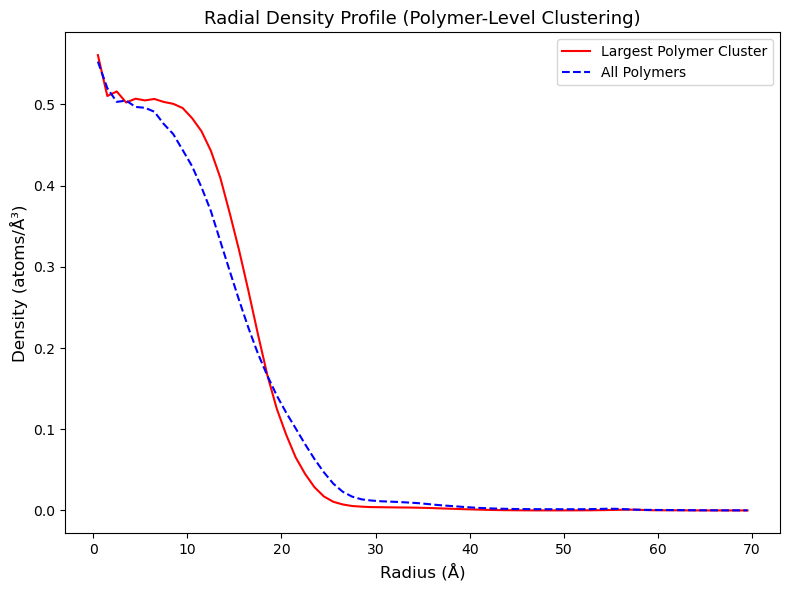

In [4]:
output_csv = 'polymerA_cluster_analysis_sphere.csv'
output_table_csv = 'polymerA_radial_density_table_sphere.csv'
output_plot = 'radialdensity_polymerA_sphere.png'

from MDAnalysis.lib.distances import distance_array

polymer_typeA = 1
cutoff = 2.5
bin_width = 1.0
max_radius = 40 * math.sqrt(3)

polymers = u.select_atoms(f"type {polymer_typeA}")

                   
fragments = polymers.fragments
n_polymers = len(fragments)

print(f"Total polymers (fragments): {n_polymers}")

class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0]*n

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return
        if self.rank[ra] < self.rank[rb]:
            self.parent[ra] = rb
        else:
            self.parent[rb] = ra
            if self.rank[ra] == self.rank[rb]:
                self.rank[ra] += 1

bins = np.arange(0, max_radius + bin_width, bin_width)
V_r = [(4/3) * np.pi * r**3 for r in bins]
shell_volumes = np.array([V_r[i+1] - V_r[i] for i in range(len(V_r)-1)])
bin_centers = 0.5 * (bins[:-1] + bins[1:])

radial_density_cluster = np.zeros(len(shell_volumes))
radial_density_all = np.zeros(len(shell_volumes))
results = []


for ts in u.trajectory[250:399]:

    polymers.wrap(compound='fragments')

    uf = UnionFind(n_polymers)

                               
    for i in range(n_polymers):
        frag_i = fragments[i]
        for j in range(i+1, n_polymers):
            frag_j = fragments[j]

            dists = distance_array(
                frag_i.positions,
                frag_j.positions,
                box=ts.dimensions
            )

            if np.any(dists <= cutoff):
                uf.union(i, j)

                   
    groups = defaultdict(list)
    for i in range(n_polymers):
        groups[uf.find(i)].append(i)

    largest_cluster_polymers = max(groups.values(), key=len)
    largest_cluster_size = len(largest_cluster_polymers)
    fraction = largest_cluster_size / n_polymers

    print(f"Frame {ts.frame}: Largest cluster = {largest_cluster_size} polymers, fraction = {fraction:.3f}")
    results.append([ts.frame, largest_cluster_size, fraction])

    largest_cluster_atoms = mda.AtomGroup(
        np.concatenate([fragments[i].indices for i in largest_cluster_polymers]),
        u
    )

            
    ref_com_cluster = largest_cluster_atoms.center_of_mass()
    distances_cluster = np.linalg.norm(
        largest_cluster_atoms.positions - ref_com_cluster,
        axis=1
    )
    hist_cluster, _ = np.histogram(distances_cluster, bins=bins)
    radial_density_cluster += hist_cluster

                  
    ref_com_all = polymers.center_of_mass()
    distances_all = np.linalg.norm(
        polymers.positions - ref_com_all,
        axis=1
    )
    hist_all, _ = np.histogram(distances_all, bins=bins)
    radial_density_all += hist_all

df = pd.DataFrame(results, columns=["Frame", "LargestClusterSize", "Fraction"])
df.to_csv(output_csv, index=False)

                                                              
                                                                        
                                             
n_frames = len(results)
if n_frames == 0:
    raise RuntimeError('No frames were processed; check the trajectory slice and atom selections.')
radial_density_cluster /= (n_frames * shell_volumes)
radial_density_all /= (n_frames * shell_volumes)

density_df = pd.DataFrame({
    "Radius(Å)": bin_centers,
    "ClusterDensity(atoms/Å³)": radial_density_cluster,
    "AllPolymerDensity(atoms/Å³)": radial_density_all
})
density_df.to_csv(output_table_csv, index=False)

plt.figure(figsize=(8,6))
plt.plot(bin_centers, radial_density_cluster, label="Largest Polymer Cluster", color='r')
plt.plot(bin_centers, radial_density_all, label="All Polymers", color='b', linestyle='--')
plt.xlabel("Radius (Å)", fontsize=12)
plt.ylabel("Density (atoms/Å³)", fontsize=12)
plt.title("Radial Density Profile (Polymer-Level Clustering)", fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

In [5]:
print(df.columns.tolist())

['Frame', 'LargestClusterSize', 'Fraction']
